# Логистическая регрессия

В этом ноутбуке разберём **логистическую регрессию** как базовый метод линейной бинарной классификации.

**Цели ноутбука:**
- Понять, почему логистическая регрессия предсказывает **вероятности классов**.
- Разобрать связь между линейной функцией и сигмоидой.
- Реализовать логистическую регрессию **с нуля** на `numpy` (градиентный спуск по логистической потере).
- Сравнить с `LogisticRegression` из `sklearn` на синтетическом датасете.

---

**Содержание:** Модель и сигмоида → Логистическая потеря → Реализация с нуля → Сравнение с sklearn.


## 1. Модель и сигмоидная функция

Рассмотрим задачу бинарной классификации, где метки классов $y \in \{0, 1\}$, а признаки $x \in \mathbb{R}^d$.

Логистическая регрессия предполагает, что **логит** (логарифм отношения шансов) линейно зависит от признаков:
$$
\log \frac{P(y=1 \mid x)}{P(y=0 \mid x)} = w^T x + b.
$$

Обозначим $p = P(y=1 \mid x)$, тогда $P(y=0 \mid x) = 1 - p$ и
$$
\log \frac{p}{1 - p} = w^T x + b.
$$

Теперь просто решим это уравнение относительно $p$:
1. Уберём логарифм, проэкспоненцировав обе части:
$$
\frac{p}{1 - p} = e^{w^T x + b}.
$$
2. Выразим $p$:
$$
 p = (1 - p)e^{w^T x + b} \\
 p = e^{w^T x + b} - p e^{w^T x + b} \\
 p + p e^{w^T x + b} = e^{w^T x + b} \\
 p(1 + e^{w^T x + b}) = e^{w^T x + b} \\
 p = \frac{e^{w^T x + b}}{1 + e^{w^T x + b}} = \frac{1}{1 + e^{-(w^T x + b)}}.
$$

То есть вероятность класса 1 есть **сигмоида** от линейной функции:
$$
P(y=1 \mid x) = \sigma(w^T x + b), \quad \sigma(z) = \frac{1}{1 + e^{-z}}.
$$
Тогда
$$
P(y=0 \mid x) = 1 - P(y=1 \mid x).
$$

На предсказании мы обычно берём класс по порогу 0.5:
$$
\hat{y}(x) = \begin{cases}
1, & \sigma(w^T x + b) \ge 0.5, \\
0, & \text{иначе}.
\end{cases}
$$


## 2. Функция потерь: логистическая (кросс-энтропия)

Хотим подобрать параметры $w, b$, которые хорошо объясняют наблюдённые метки.

Для одного объекта $(x_i, y_i)$ вероятность правильной метки:
$$
P(y_i \mid x_i) = \sigma(z_i)^{y_i} (1 - \sigma(z_i))^{1 - y_i}, \quad z_i = w^T x_i + b.
$$

Максимизация правдоподобия эквивалентна минимизации **отрицательного лог-правдоподобия**, то есть **логистической потери (кросс-энтропии)**:
$$
\ell_i(w, b) = - \bigl[ y_i \log \sigma(z_i) + (1 - y_i) \log (1 - \sigma(z_i)) \bigr].
$$

Общая функция потерь для выборки из $N$ объектов:
$$
L(w, b) = \frac{1}{N} \sum_{i=1}^N \ell_i(w, b).
$$

К ней часто добавляют **L2-регуляризацию** (штраф за большие веса), но в первой реализации для простоты можно её опустить или сделать опциональной.


### Подробный вывод логистической потери

Перепишем вероятность одной точки в виде Бернулли:
$$
P(y_i \mid x_i) = \sigma(z_i)^{y_i} (1 - \sigma(z_i))^{1 - y_i}, \quad z_i = w^T x_i + b.
$$
Проверка:
- если $y_i = 1$, то $P(y_i \mid x_i) = \sigma(z_i)$;
- если $y_i = 0$, то $P(y_i \mid x_i) = 1 - \sigma(z_i)$.

Тогда **лог-правдоподобие** одного объекта:
$$
\log P(y_i \mid x_i) = y_i \log \sigma(z_i) + (1 - y_i) \log (1 - \sigma(z_i)).
$$
А вклад в функцию потерь — это **отрицательное** лог-правдоподобие:
$$
\ell_i(w, b) = - \log P(y_i \mid x_i)
= - \bigl[ y_i \log \sigma(z_i) + (1 - y_i) \log (1 - \sigma(z_i)) \bigr].
$$
Итоговая функция потерь усредняет вклады по всем объектам:
$$
L(w, b) = \frac{1}{N} \sum_{i=1}^N \ell_i(w, b).
$$

## 3. Градиенты для градиентного спуска

Обозначим $\hat{p}_i = \sigma(z_i) = P(y_i = 1 \mid x_i)$.
Тогда логистическая потеря для одного объекта:
$$
\ell_i = - \bigl[ y_i \log \hat{p}_i + (1 - y_i) \log (1 - \hat{p}_i) \bigr].
$$

Градиенты (без регуляризации):
$$
\frac{\partial L}{\partial w} = \frac{1}{N} \sum_{i=1}^N (\hat{p}_i - y_i) x_i, \quad
\frac{\partial L}{\partial b} = \frac{1}{N} \sum_{i=1}^N (\hat{p}_i - y_i).
$$

Это удобно реализовать в векторном виде и использовать **градиентный спуск**:
- инициализируем $w, b$,
- на каждой итерации считаем градиенты и делаем шаг в сторону уменьшения потерь.


## 4. Синтетические данные

Сгенерируем двумерные данные для бинарной классификации (что-то вроде двух перекрывающихся кластеров), чтобы:
- обучить логистическую регрессию с нуля,
- сравнить с `LogisticRegression` из `sklearn`,
- визуализировать границу решений.


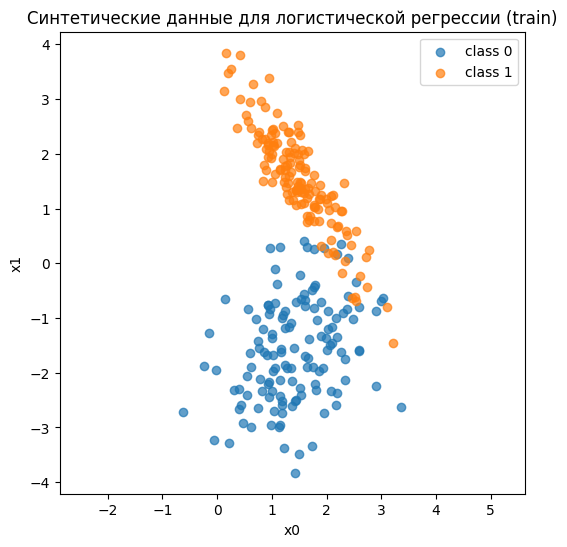

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

X, y = make_classification(
    n_samples=400,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color="tab:blue", alpha=0.7, label="class 0")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color="tab:orange", alpha=0.7, label="class 1")
plt.xlabel("x0")
plt.ylabel("x1")
plt.title("Синтетические данные для логистической регрессии (train)")
plt.legend()
plt.axis("equal")
plt.show()


## 5. Реализация логистической регрессии с нуля

Сделаем простой класс `LogisticRegressionScratch` с методом обучения по **полному градиентному спуску**:
- без регуляризации (или с опциональной L2),
- с возможностью получать как классы, так и вероятности.


In [6]:
class LogisticRegressionScratch:
    def __init__(self, lr: float = 0.1, n_epochs: int = 1000, l2: float = 0.0):
        self.lr = lr
        self.n_epochs = n_epochs
        self.l2 = l2  # коэффициент L2-регуляризации
        self.w_ = None
        self.b_ = None

    @staticmethod
    def _sigmoid(z: np.ndarray) -> np.ndarray:
        return 1.0 / (1.0 + np.exp(-z))

    def fit(self, X: np.ndarray, y: np.ndarray):
        X = np.asarray(X)
        y = np.asarray(y)
        n_samples, n_features = X.shape

        self.w_ = np.zeros(n_features)
        self.b_ = 0.0

        for epoch in range(self.n_epochs):
            z = X @ self.w_ + self.b_
            p = self._sigmoid(z)  # p = P(y=1 | x)

            # Градиенты логистической потери + L2
            error = p - y  # shape (n_samples,)
            grad_w = (X.T @ error) / n_samples + self.l2 * self.w_
            grad_b = error.mean()

            self.w_ -= self.lr * grad_w
            self.b_ -= self.lr * grad_b

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X)
        z = X @ self.w_ + self.b_
        p1 = self._sigmoid(z)
        return np.vstack([1 - p1, p1]).T  # shape (n_samples, 2)

    def predict(self, X: np.ndarray) -> np.ndarray:
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)


log_reg_scratch = LogisticRegressionScratch(lr=0.1, n_epochs=1000, l2=0.0)
log_reg_scratch.fit(X_train_scaled, y_train)

y_pred_train = log_reg_scratch.predict(X_train_scaled)
y_pred_test = log_reg_scratch.predict(X_test_scaled)

train_acc = (y_pred_train == y_train).mean()
test_acc = (y_pred_test == y_test).mean()

print(f"Scratch logistic regression train accuracy: {train_acc:.3f}")
print(f"Scratch logistic regression test  accuracy: {test_acc:.3f}")


Scratch logistic regression train accuracy: 0.946
Scratch logistic regression test  accuracy: 0.942


## 6. Визуализация границы решений (реализация с нуля)

Построим разделяющую прямую для логистической регрессии в исходном пространстве признаков (2D).


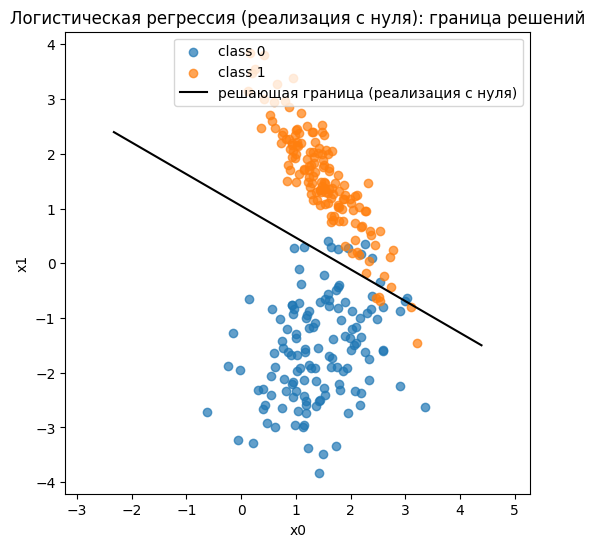

In [7]:
# Восстановим w и b в исходном масштабе признаков
w_scaled = log_reg_scratch.w_
b_scaled = log_reg_scratch.b_

scale = scaler.scale_
mean_ = scaler.mean_

w_orig = w_scaled / scale
b_orig = b_scaled - np.dot(w_scaled, mean_ / scale)

# Линия w^T x + b = 0 в исходном пространстве
x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
xs = np.linspace(x_min, x_max, 200)
ys = -(w_orig[0] * xs + b_orig) / w_orig[1]

plt.figure(figsize=(6, 6))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color="tab:blue", alpha=0.7, label="class 0")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color="tab:orange", alpha=0.7, label="class 1")
plt.plot(xs, ys, color="k", label="решающая граница (реализация с нуля)")
plt.xlabel("x0")
plt.ylabel("x1")
plt.title("Логистическая регрессия (реализация с нуля): граница решений")
plt.legend()
plt.axis("equal")
plt.show()


### Примечание: зачем мы восстанавливаем `w` и `b` в исходном масштабе

Мы обучали логистическую регрессию на **стандартизованных признаках**:
$$
x_{std} = \frac{x - \text{mean}}{\text{scale}},
$$
и модель учила линейную функцию в этих координатах:
$$
z = w_{scaled}^T x_{std} + b_{scaled}.
$$
Если мы хотим нарисовать разделяющую прямую/гиперплоскость в **исходных координатах** $x$, нужно найти такие $w_{orig}, b_{orig}$, что
$$
w_{orig}^T x + b_{orig} = w_{scaled}^T x_{std} + b_{scaled}\quad\text{для любого }x.
$$
Подставляя $x_{std}$ и раскрывая скобки, получаем:
$$
w_{orig,j} = \frac{w_{scaled,j}}{\text{scale}_j}, \quad
b_{orig} = b_{scaled} - \sum_j \frac{w_{scaled,j}\, \text{mean}_j}{\text{scale}_j}.
$$
Именно это и реализовано в коде:
```python
w_orig = w_scaled / scale
b_orig = b_scaled - np.dot(w_scaled, mean_ / scale)
```
Так мы получаем эквивалентную линейную модель в исходном пространстве признаков, и линия $w_{orig}^T x + b_{orig} = 0$ действительно совпадает с границей решений обученной модели.

## 7. Логистическая регрессия из `sklearn`

Теперь воспользуемся `sklearn.linear_model.LogisticRegression` и сравним результаты с нашей реализацией:
- точность на train/test,
- границу решений.


sklearn LogisticRegression train accuracy: 0.946
sklearn LogisticRegression test  accuracy: 0.950


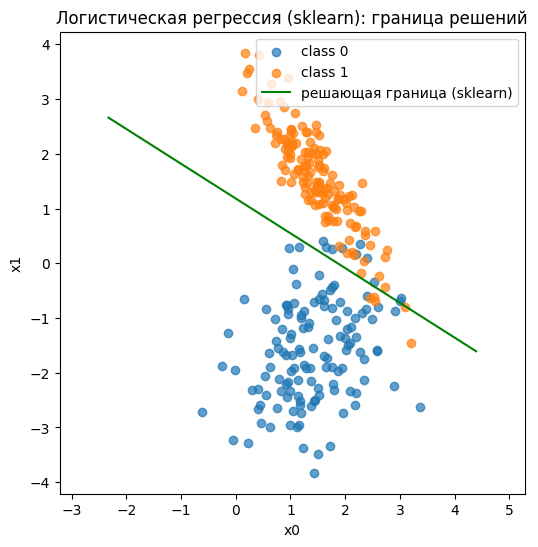

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_reg = LogisticRegression(solver="lbfgs")
log_reg.fit(X_train_scaled, y_train)

y_pred_train_sk = log_reg.predict(X_train_scaled)
y_pred_test_sk = log_reg.predict(X_test_scaled)

train_acc_sk = accuracy_score(y_train, y_pred_train_sk)
test_acc_sk = accuracy_score(y_test, y_pred_test_sk)

print(f"sklearn LogisticRegression train accuracy: {train_acc_sk:.3f}")
print(f"sklearn LogisticRegression test  accuracy: {test_acc_sk:.3f}")

# Визуализация границы решений sklearn-модели
w_scaled_sk = log_reg.coef_[0]
b_scaled_sk = log_reg.intercept_[0]

w_orig_sk = w_scaled_sk / scale
b_orig_sk = b_scaled_sk - np.dot(w_scaled_sk, mean_ / scale)

ys_sk = -(w_orig_sk[0] * xs + b_orig_sk) / w_orig_sk[1]

plt.figure(figsize=(6, 6))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color="tab:blue", alpha=0.7, label="class 0")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color="tab:orange", alpha=0.7, label="class 1")
plt.plot(xs, ys_sk, color="green", label="решающая граница (sklearn)")
plt.xlabel("x0")
plt.ylabel("x1")
plt.title("Логистическая регрессия (sklearn): граница решений")
plt.legend()
plt.axis("equal")
plt.show()


## Выводы

- Логистическая регрессия — линейный вероятностный классификатор: вероятности классов задаются сигмоидой от линейной комбинации признаков; оптимизируют кросс-энтропийную (логистическую) потерю.
- Градиенты этой потери легко вывести и реализовать с нуля (градиентный спуск); sklearn использует более эффективные оптимизаторы и регуляризацию, но концептуально реализует ту же идею.
- Линейная граница решений интерпретируема; при необходимости нелинейности — признаки высшего порядка или другие модели.